# Military damage crop labeling

Run the fine-tuned Humvee component detector on candidate source images, export every predicted component crop with a stable ID, and display contact sheets grouped into `mobility`, `structure`, and `mission_equipment`.

This is a detector-driven annotation run. The boxes are predictions, not ground-truth component annotations. Each run records the checkpoint hash, source image hash, detector class/confidence, bounding box, crop path, and ID ordering. Existing runs are never overwritten.

In [1]:
# 1. Configuration
import sys
from collections import Counter
from pathlib import Path

from IPython.display import display
from PIL import Image as PILImage

ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'third_party' / 'YOLOX').is_dir()),
    None,
)
assert ROOT is not None, 'Run this notebook from the CRATER repository or one of its subdirectories.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from tools.data.damage_crop_annotation import (
    PART_GROUP_ORDER,
    SOURCE6_PART_GROUPS,
    contact_sheet_paths,
    create_annotation_run,
    create_head_splits,
    discover_source_images,
    load_coco_class_names,
    run_yolox_inference,
    validate_and_merge_labels,
)

# Change RUN_NAME for every new source/model/threshold run. Existing runs are protected.
RUN_NAME = 'commons_damage_subset16_source6_v1'
PREPARED_DATASET_NAME = 'partial_labels_split_v1'
SOURCE_COLLECTIONS = [
    {
        'name': 'commons_damage_subset16_v1',
        'image_dir': ROOT / 'datasets' / 'military' / 'damage' / 'source' / 'commons_labeling_subset_v1' / 'images',
        'catalog': ROOT / 'datasets' / 'military' / 'damage' / 'source' / 'commons_labeling_subset_v1' / 'selection_manifest.csv',
        'local_file_field': 'subset_local_file',
    },
]
# This fixed 16-image subset spans intact, moderate, and severe vehicle damage.
CLASS_ANNOTATIONS = ROOT / 'datasets' / 'military' / 'components' / 'annotations' / 'humvee_source6_instances_test.json'
EXPERIMENT_FILE = ROOT / 'experiments' / 'detection' / 'yolox_s_crater6.py'
CHECKPOINT_FILE = ROOT / 'outputs' / 'detection' / 'humvee_source6' / 'carparts_initialized_seed42' / 'best_ckpt.pth'
RUN_DIR = ROOT / 'datasets' / 'military' / 'damage' / 'annotation_runs' / 'predicted_crops' / RUN_NAME

INFERENCE_CONFIDENCE = 0.25
NMS_THRESHOLD = None  # None uses the experiment default.
CROP_PADDING_FRACTION = 0.08
DEVICE = 'auto'  # CUDA when available, otherwise CPU.
SPLIT_RATIOS = (0.70, 0.15, 0.15)
SPLIT_SEED = 42

print(f'Repository: {ROOT}')
print(f'Output run: {RUN_DIR}')

Repository: c:\Users\jrwhite\Documents\Projects\crater
Output run: c:\Users\jrwhite\Documents\Projects\crater\datasets\military\damage\annotation_runs\predicted_crops\commons_damage_subset16_source6_v1


In [2]:
# 2. Validate inputs and discover catalog-approved local images
required_paths = [CLASS_ANNOTATIONS, EXPERIMENT_FILE, CHECKPOINT_FILE]
for collection in SOURCE_COLLECTIONS:
    required_paths.append(collection['image_dir'])
    if collection['catalog'] is not None:
        required_paths.append(collection['catalog'])
for required_path in required_paths:
    assert required_path.exists(), f'Missing required input: {required_path}'
image_paths = []
for collection in SOURCE_COLLECTIONS:
    collection_images = discover_source_images(
        collection['image_dir'],
        collection['catalog'],
        local_file_field=collection.get('local_file_field', 'local_file'),
    )
    image_paths.extend(collection_images)
    print(f"{collection['name']}: {len(collection_images)} images")
image_paths = sorted(set(image_paths), key=lambda path: path.as_posix().casefold())
class_names = load_coco_class_names(CLASS_ANNOTATIONS)
print(f'Images ready for inference: {len(image_paths)}')
print('Detector classes and damage groups:')
for class_name in class_names:
    print(f'  {class_name:18s} -> {SOURCE6_PART_GROUPS[class_name]}')
print('First source:', image_paths[0])

commons_damage_subset16_v1: 16 images
Images ready for inference: 16
Detector classes and damage groups:
  wheel_tire         -> mobility
  windshield         -> structure
  door               -> structure
  engine_bay         -> structure
  weapon_station     -> mission_equipment
  comms_equipment    -> mission_equipment
First source: C:\Users\jrwhite\Documents\Projects\crater\datasets\military\damage\source\commons_labeling_subset_v1\images\commons_10482322_APC_damaged_by_armour-piercing_rounds.jpg


In [3]:
# 3. Run detector inference (the long-running cell)
if RUN_DIR.exists():
    candidates = None
    inference_metadata = None
    print(f'Reusing existing annotation run: {RUN_DIR}')
else:
    candidates, inference_metadata = run_yolox_inference(
        repo_root=ROOT,
        image_paths=image_paths,
        experiment_file=EXPERIMENT_FILE,
        checkpoint_file=CHECKPOINT_FILE,
        class_names=class_names,
        confidence=INFERENCE_CONFIDENCE,
        nms_threshold=NMS_THRESHOLD,
        device_name=DEVICE,
    )
    assert candidates, 'The detector produced no crops. Check the source images and confidence threshold.'
    print(f'Candidate crops: {len(candidates)}')
    print('By group:', dict(Counter(item['part_group'] for item in candidates)))
    print('By detector class:', dict(Counter(item['detector_class'] for item in candidates)))
    print('Checkpoint SHA-256:', inference_metadata['checkpoint_sha256'])

Reusing existing annotation run: c:\Users\jrwhite\Documents\Projects\crater\datasets\military\damage\annotation_runs\predicted_crops\commons_damage_subset16_source6_v1


In [4]:
# 4. Atomically create crops, manifests, contact sheets, and blank CSV templates
if RUN_DIR.exists():
    annotation_run_dir = RUN_DIR
else:
    annotation_run_dir = create_annotation_run(
        candidates=candidates,
        run_dir=RUN_DIR,
        repo_root=ROOT,
        inference_metadata=inference_metadata,
        crop_padding_fraction=CROP_PADDING_FRACTION,
    )
print('Created annotation run:', annotation_run_dir)
print('Crop manifest:', annotation_run_dir / 'crops_manifest.csv')
for group in PART_GROUP_ORDER:
    print(f'{group} template:', annotation_run_dir / 'label_templates' / f'{group}.csv')

Created annotation run: c:\Users\jrwhite\Documents\Projects\crater\datasets\military\damage\annotation_runs\predicted_crops\commons_damage_subset16_source6_v1
Crop manifest: c:\Users\jrwhite\Documents\Projects\crater\datasets\military\damage\annotation_runs\predicted_crops\commons_damage_subset16_source6_v1\crops_manifest.csv
mobility template: c:\Users\jrwhite\Documents\Projects\crater\datasets\military\damage\annotation_runs\predicted_crops\commons_damage_subset16_source6_v1\label_templates\mobility.csv
structure template: c:\Users\jrwhite\Documents\Projects\crater\datasets\military\damage\annotation_runs\predicted_crops\commons_damage_subset16_source6_v1\label_templates\structure.csv
mission_equipment template: c:\Users\jrwhite\Documents\Projects\crater\datasets\military\damage\annotation_runs\predicted_crops\commons_damage_subset16_source6_v1\label_templates\mission_equipment.csv



MOBILITY: 3 contact-sheet page(s)


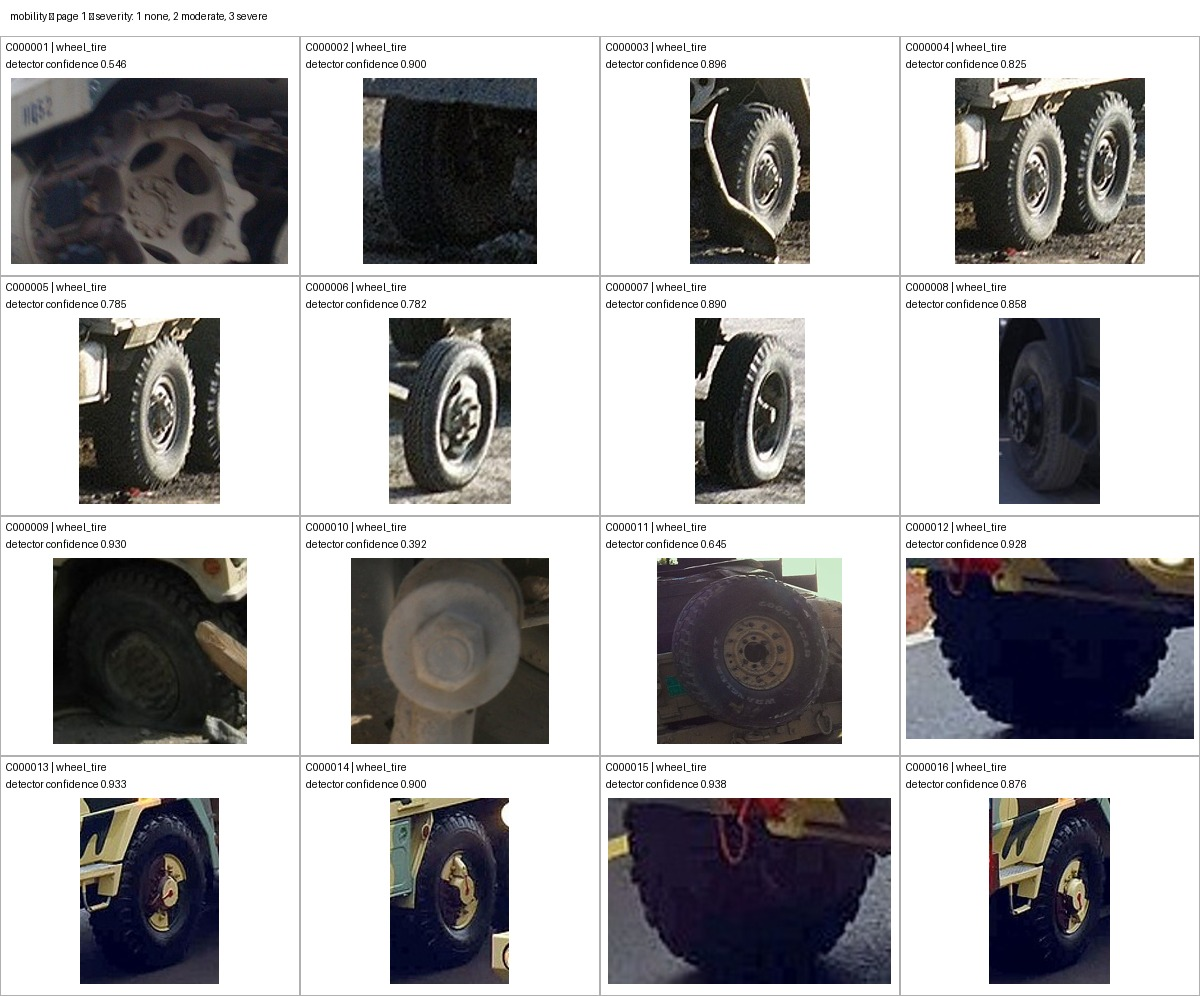

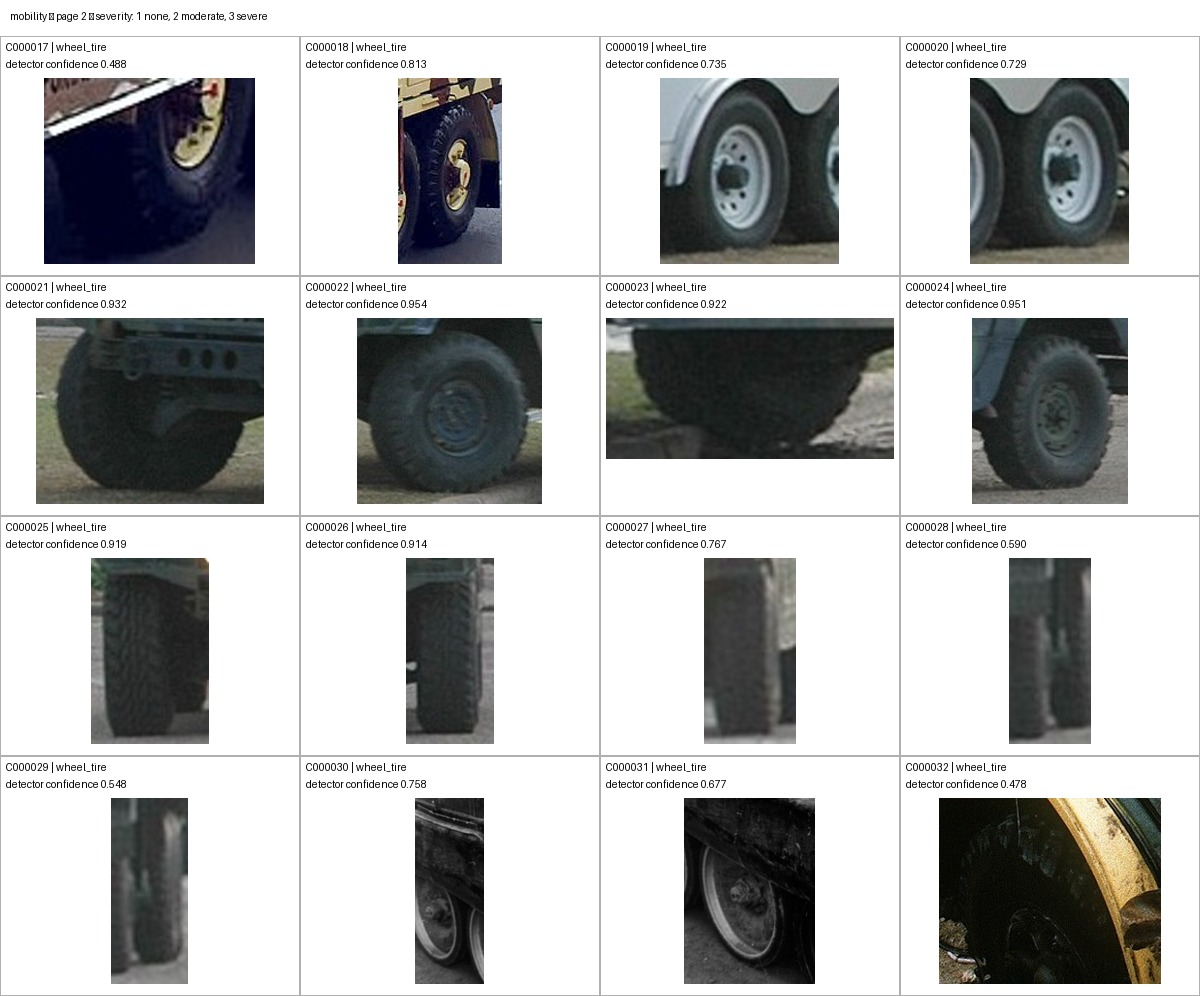

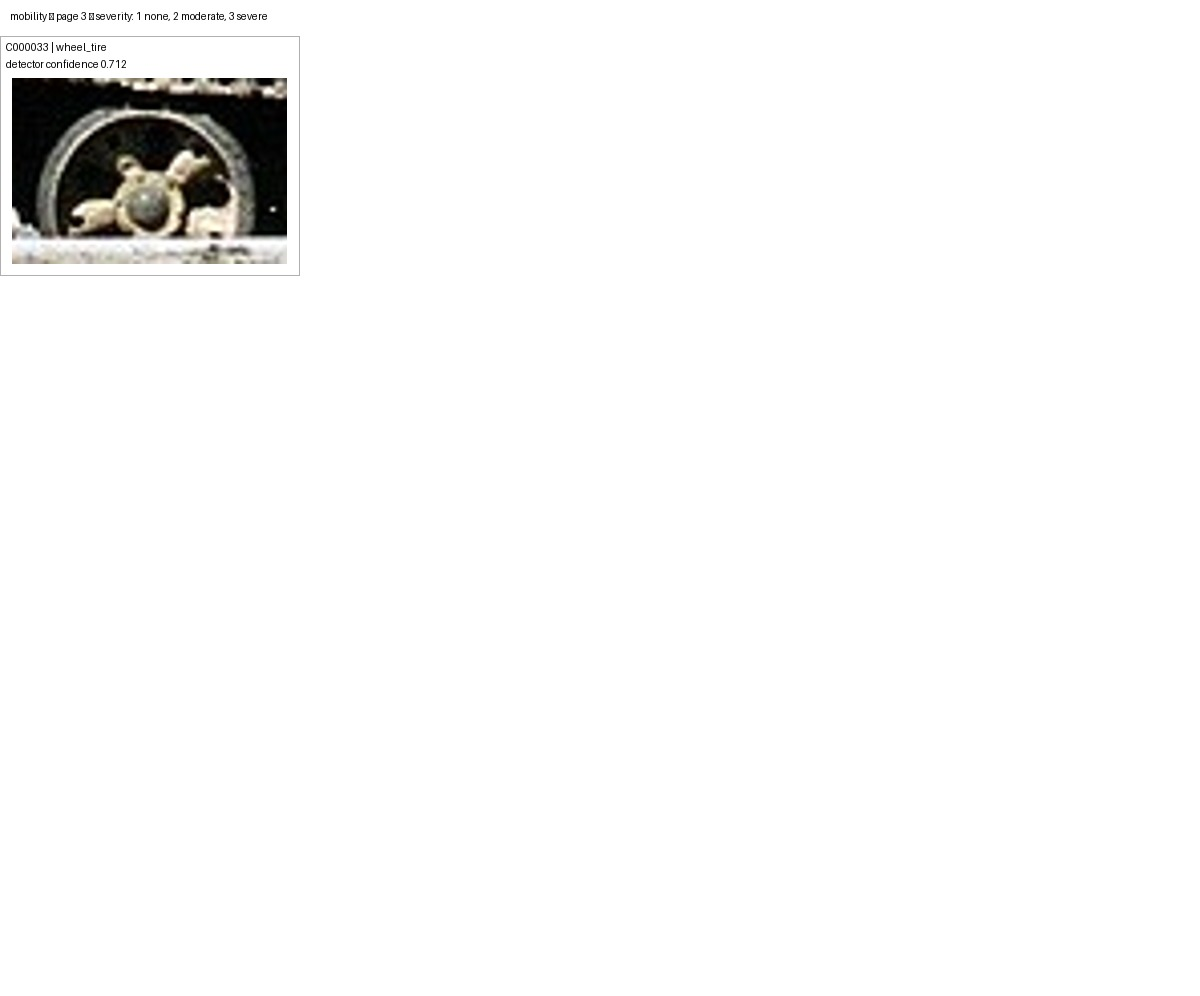


STRUCTURE: 2 contact-sheet page(s)


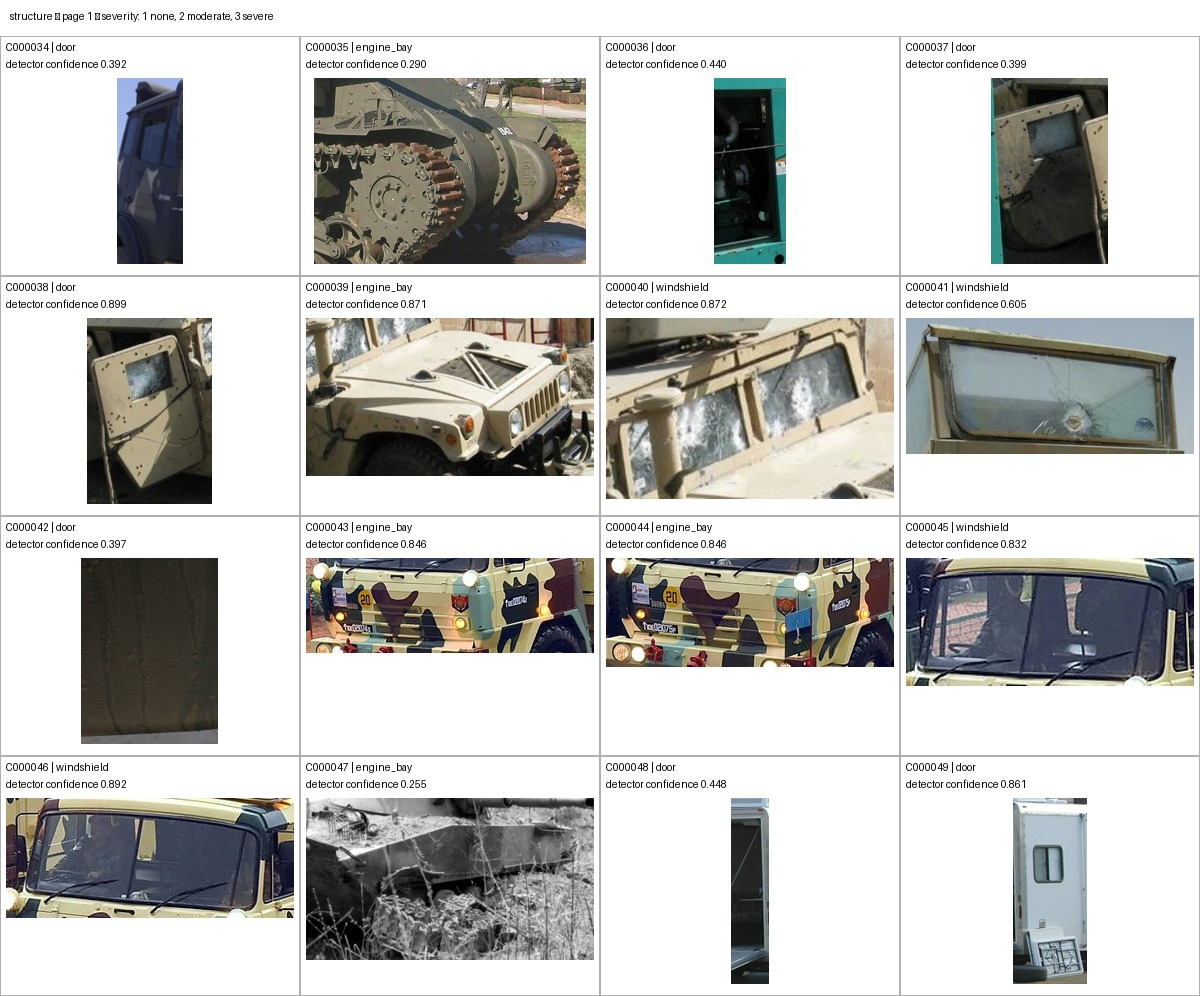

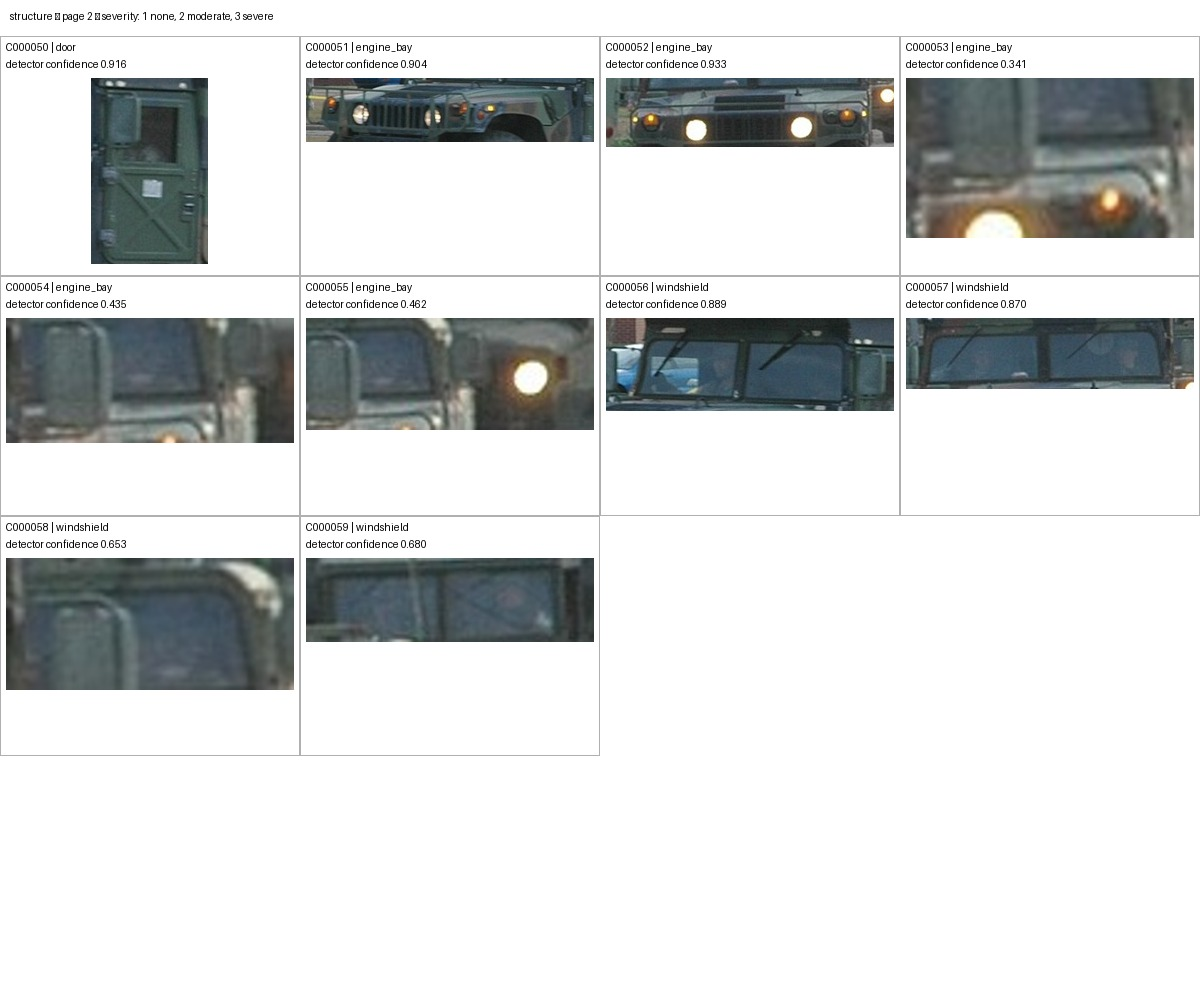


MISSION_EQUIPMENT: 1 contact-sheet page(s)


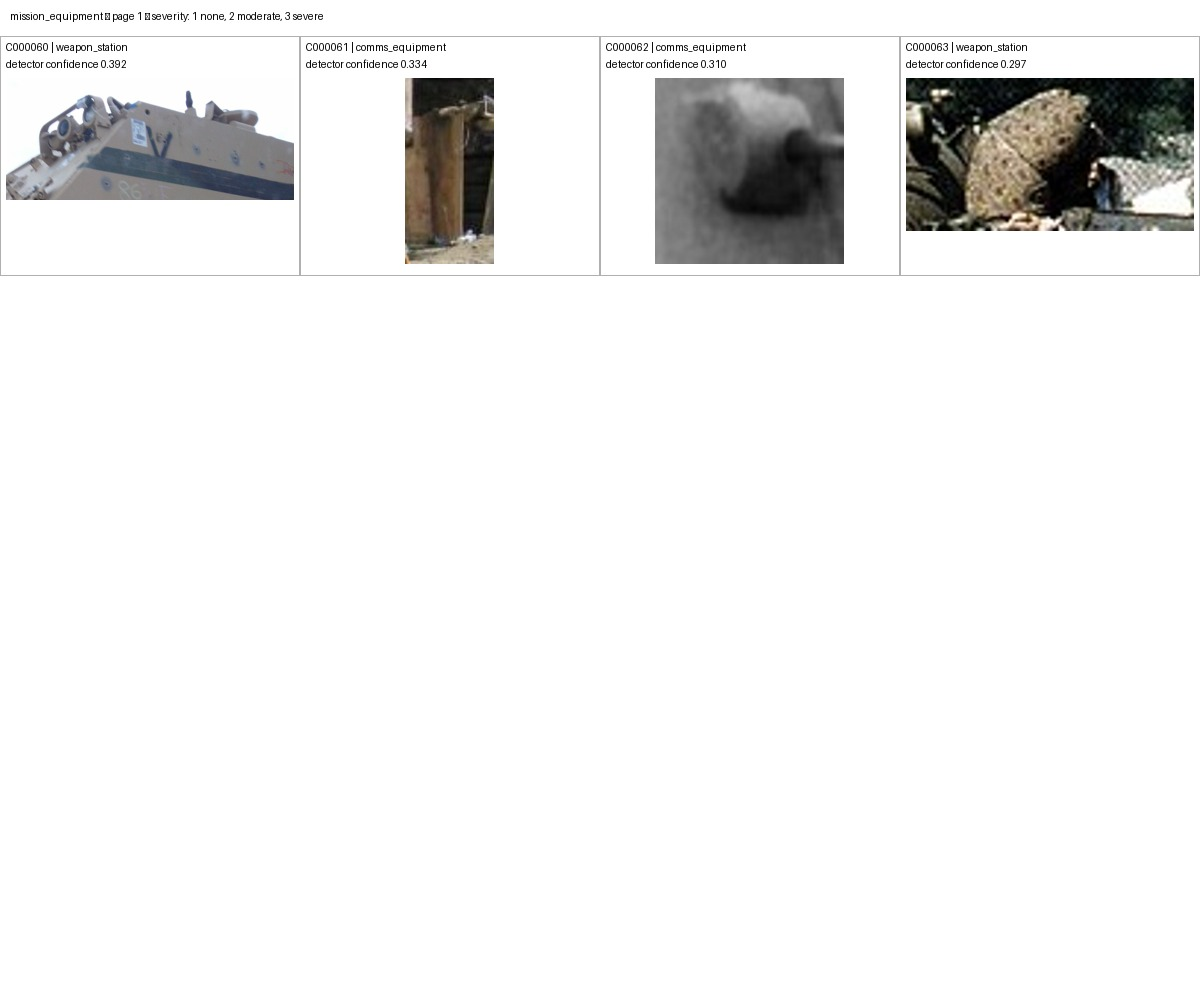

In [5]:
# 5. Display every crop on paginated contact sheets, grouped by part group
sheets_by_group = contact_sheet_paths(annotation_run_dir)
for group in PART_GROUP_ORDER:
    sheets = sheets_by_group[group]
    print(f'\n{group.upper()}: {len(sheets)} contact-sheet page(s)')
    for sheet_path in sheets:
        with PILImage.open(sheet_path) as sheet:
            display(sheet.copy())

## Label the crops

There is one template in `label_templates/` for each part group. Keep the two columns exactly as written and fill every `damage_severity` value:

- `1` — none
- `2` — moderate
- `3` — severe

Upload the completed files as `label_uploads/mobility.csv`, `label_uploads/structure.csv`, and `label_uploads/mission_equipment.csv`. Do not change `crop_id`. You may leave `damage_severity` blank: blank or omitted IDs are excluded, and neither their labels nor crop images enter the prepared datasets. The next cell validates IDs and nonblank severity values, then creates source-grouped train/validation/test crops for each head.

In [ ]:
# 6. Run this cell after uploading all three completed CSVs
uploaded_csvs = {
    group: annotation_run_dir / 'label_uploads' / f'{group}.csv'
    for group in PART_GROUP_ORDER
}
missing_uploads = [path for path in uploaded_csvs.values() if not path.is_file()]
if missing_uploads:
    print('Waiting for completed label uploads:')
    for path in missing_uploads:
        print(' ', path)
else:
    validated_labels = validate_and_merge_labels(annotation_run_dir, uploaded_csvs)
    print('Validated and merged nonblank labels:', validated_labels)
    prepared_output = annotation_run_dir / 'prepared_datasets' / PREPARED_DATASET_NAME
    prepared_dataset = create_head_splits(
        run_dir=annotation_run_dir,
        validated_labels_csv=validated_labels,
        output_dir=prepared_output,
        split_ratios=SPLIT_RATIOS,
        seed=SPLIT_SEED,
    )
    print('Prepared per-head datasets:', prepared_dataset)